In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:

from google.colab import files

uploaded = files.upload()

Saving all_transactions.csv to all_transactions.csv
Saving all_users - Copy.csv to all_users - Copy.csv


In [ ]:
##-LOAD DATA
users = pd.read_csv('/content/all_users - Copy.csv')
transactions = pd.read_csv('/content/all_transactions.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
users = pd.read_csv('/content/all_users - Copy.csv')

users.head()

,User_ID,Name,Age,Join_Date
0,PP0000001,Holly Rivera,56,2025-06-17
1,PP0000002,Kevin Lopez,46,2023-12-10
2,PP0000003,Douglas Roberts,32,2024-09-14
3,PP0000004,Walter Davila,60,2023-10-19
4,PP0000005,Grace Blake,25,2025-03-10


In [ ]:
import pandas as pd
TRANSACTIONS = pd.read_csv('/content/all_transactions.csv')

TRANSACTIONS.head()

,Transaction_ID,Amount,User_ID,Service,Service Type,Payment_Status,Reason,Date
0,RCG_0C338474B366,926.59,PP0021371,Recharge_Bills,FASTag Recharge,Successful,Successful,09-06-2024
1,RCG_6B3B86B07A76,1211.64,PP0002388,Recharge_Bills,DTH,Successful,Successful,04-08-2024
2,RCG_767822392A0E,746.27,PP1101831,Recharge_Bills,Cable TV,Successful,Successful,19-02-2024
3,RCG_527E6AC74B11,1319.89,PP0033099,Recharge_Bills,Mobile Recharge,Successful,Successful,22-12-2024
4,RCG_6B50A8C694E1,112.44,PP1059869,Recharge_Bills,Cable TV,Successful,Successful,07-09-2024


In [ ]:
##INSPECT DATA
users.head()

transactions.head()

users.info()

transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107658 entries, 0 to 107657
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   User_ID    107658 non-null  object        
 1   Name       107658 non-null  object        
 2   Age        107658 non-null  int64         
 3   Join_Date  107658 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 3.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Transaction_ID  300000 non-null  object        
 1   Amount          300000 non-null  float64       
 2   User_ID         300000 non-null  object        
 3   Service         300000 non-null  object        
 4   Service Type    300000 non-null  object        
 5   Payment_Status  300000 non-null  object        

In [ ]:
##Check Missing Values
users.isnull().sum()

transactions.isnull().sum()

,0
Transaction_ID,0
Amount,0
User_ID,0
Service,0
Service Type,0
Payment_Status,0
Reason,0
Date,0


In [ ]:
##Remove Duplicates
users = users.drop_duplicates()

transactions = transactions.drop_duplicates()

In [ ]:
##Convert Data Types
users['Join_Date'] = pd.to_datetime(users['Join_Date'])

transactions['Date'] = pd.to_datetime(transactions['Date'], format='%d-%m-%Y')

transactions['Amount'] = pd.to_numeric(transactions['Amount'])

## Merge DataFrames

In [ ]:
df = pd.merge(transactions, users, on='User_ID', how='left')
display(df.head())
display(df.info())

,Transaction_ID,Amount,User_ID,Service,Service Type,Payment_Status,Reason,Date,Name,Age,Join_Date
0,RCG_0C338474B366,926.59,PP0021371,Recharge_Bills,FASTag Recharge,Successful,Successful,2024-06-09,Katherine Howard,50,2023-08-28
1,RCG_6B3B86B07A76,1211.64,PP0002388,Recharge_Bills,DTH,Successful,Successful,2024-08-04,Kimberly Mueller,34,2024-08-10
2,RCG_767822392A0E,746.27,PP1101831,Recharge_Bills,Cable TV,Successful,Successful,2024-02-19,Scott Davis,36,2023-09-28
3,RCG_527E6AC74B11,1319.89,PP0033099,Recharge_Bills,Mobile Recharge,Successful,Successful,2024-12-22,Gina Williams,25,2023-10-09
4,RCG_6B50A8C694E1,112.44,PP1059869,Recharge_Bills,Cable TV,Successful,Successful,2024-09-07,Timothy Hernandez,58,2024-07-13


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   Transaction_ID  300000 non-null  object        
 1   Amount          300000 non-null  float64       
 2   User_ID         300000 non-null  object        
 3   Service         300000 non-null  object        
 4   Service Type    300000 non-null  object        
 5   Payment_Status  300000 non-null  object        
 6   Reason          300000 non-null  object        
 7   Date            300000 non-null  datetime64[ns]
 8   Name            300000 non-null  object        
 9   Age             300000 non-null  int64         
 10  Join_Date       300000 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(7)
memory usage: 25.2+ MB


None

In [ ]:
##Total Users
df['User_ID'].nunique()

100761

In [ ]:
##Total Transactions
df['Transaction_ID'].count()

np.int64(300000)

In [ ]:
##Total Revenue billion
round(df['Amount'].sum()/1000000000,2)

np.float64(3.47)

In [ ]:
##Average Transaction
round(df['Amount'].mean(),2)

np.float64(11581.07)

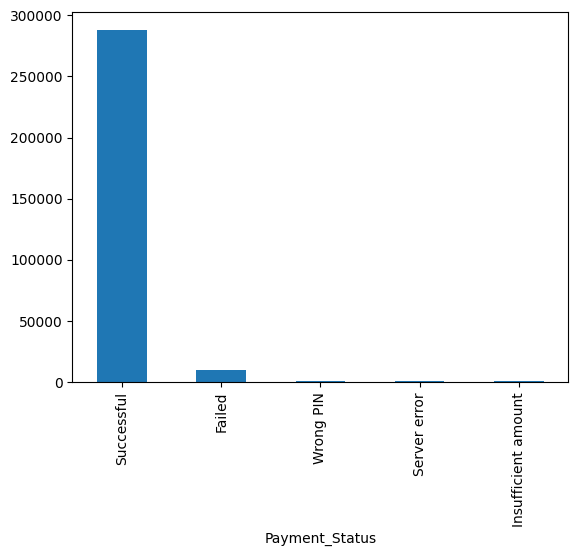

In [ ]:
#ayment Status Analysis
df['Payment_Status'].value_counts()
df['Payment_Status'].value_counts().plot(kind='bar')
plt.show()

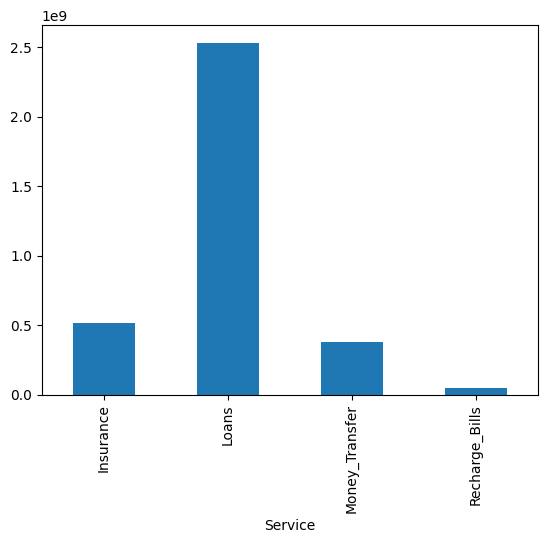

In [ ]:
###Service Analysis
df.groupby('Service')['Amount'].sum().sort_values(ascending=False)
df.groupby('Service')['Amount'].sum().plot(kind='bar')
plt.show()

In [ ]:
##Age Group Analysis
df.groupby('Age')['Amount'].sum()

,Amount
Age,
18,81984176.92
19,80598754.25
20,83507896.48
21,81137258.19
22,85368026.12
23,80560370.03
24,75149629.19
25,79661776.51
26,79847718.89


In [ ]:
##Top spending age:

df.groupby('Age')['Amount'].sum().sort_values(ascending=False).head()

,Amount
Age,
22,85368026.12
40,85328533.44
55,84366294.20
50,83911913.18
20,83507896.48


In [ ]:
##Failed Transaction Analysis
failed = df[df['Payment_Status']=='Failed']

failed['Reason'].value_counts()



,count
Reason,
Server error,3361
Wrong PIN,3315
Insufficient amount,3304


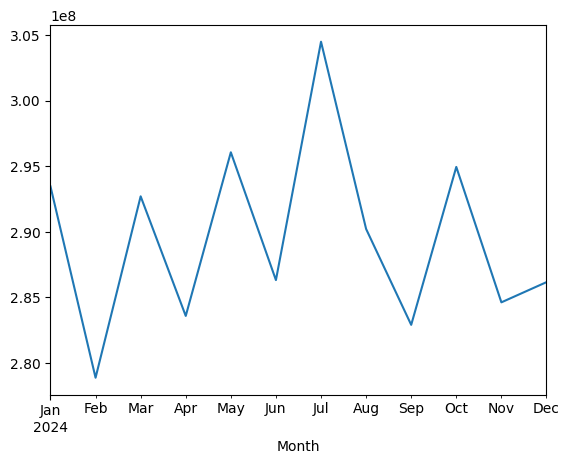

In [ ]:
##Monthly Revenue Trend
df['Month'] = df['Date'].dt.to_period('M')

monthly = df.groupby('Month')['Amount'].sum()

monthly.plot()
plt.show()

In [ ]:
###Top 10 Users
top_users = df.groupby('Name')['Amount'].sum()

top_users.sort_values(ascending=False).head(10)

,Amount
Name,
Michael Smith,1817706.21
Jennifer Williams,1567635.26
Michael Brown,1273099.49
Christopher Brown,1232907.35
Michael Jones,1210406.36
Robert Smith,1199850.73
Christopher Smith,1099431.38
James Johnson,1074389.72
John Smith,1065267.62


# New Section